<a href="https://colab.research.google.com/github/yuva0567890/APAASSIGNMENT8/blob/main/APA8dataset1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# DATASET 1 - AGRICULTURAL CROP-YIELD PREDICTION
# CELL 1: IMPORTS AND FOLDER SETUP
# ============================================================

import os
import json
import hashlib
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

warnings.filterwarnings("ignore")

SEED = 42

os.makedirs("figures_dataset1", exist_ok=True)
os.makedirs("models_dataset1", exist_ok=True)
os.makedirs("artifacts_dataset1", exist_ok=True)

print("Libraries imported successfully.")
print("Dataset 1 folders created successfully.")

Libraries imported successfully.
Dataset 1 folders created successfully.


In [3]:
# ============================================================
# CELL 2: LOAD DATASET 1
# ============================================================

import os
import pandas as pd
from IPython.display import display

# Existing uploaded file path in Google Colab
DATASET_PATH = "/content/APY.csv"

# Check whether the file already exists
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        "APY.csv was not found in /content. "
        "Please upload the file once using the Colab Files panel."
    )

# Load Dataset 1
df_raw = pd.read_csv(DATASET_PATH)

print("Dataset 1 loaded successfully.")
print("File path:", DATASET_PATH)
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

print("\nFirst five rows:")
display(df_raw.head())

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame(name="Data Type"))

Dataset 1 loaded successfully.
File path: /content/APY.csv
Number of rows: 345336
Number of columns: 8

First five rows:


,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75



Column names:
['State', 'District ', 'Crop', 'Crop_Year', 'Season', 'Area ', 'Production', 'Yield']

Data types:


,Data Type
State,object
District,object
Crop,object
Crop_Year,int64
Season,object
Area,float64
Production,float64
Yield,float64


In [4]:
# ============================================================
# CELL 3: INITIAL DATA INSPECTION
# ============================================================

df = df_raw.copy()

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.lower()
)

print("Cleaned column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing-value summary:")
missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing_Values": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean().values * 100
    ).round(3)
})

display(missing_summary)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nInitial data shape:", df.shape)

Cleaned column names:
['state', 'district', 'crop', 'crop_year', 'season', 'area', 'production', 'yield']

Data types:


,Data Type
state,object
district,object
crop,object
crop_year,int64
season,object
area,float64
production,float64
yield,float64



Missing-value summary:


,Column,Missing_Values,Missing_Percentage
0,state,0,0.000
1,district,0,0.000
2,crop,9,0.003
3,crop_year,0,0.000
4,season,0,0.000
5,area,0,0.000
6,production,4948,1.433
7,yield,0,0.000



Duplicate rows: 0

Initial data shape: (345336, 8)


In [5]:
# ============================================================
# CELL 4: COLUMN VALIDATION
# ============================================================

required_columns = [
    "state",
    "district",
    "crop",
    "crop_year",
    "season",
    "area",
    "production",
    "yield"
]

missing_required_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Required columns are missing: {missing_required_columns}"
    )

print("All required columns are available.")
print("Required-column validation passed.")

All required columns are available.
Required-column validation passed.


In [6]:
# ============================================================
# CELL 5: NUMERIC CONVERSION AND SOURCE AUDIT
# ============================================================

numeric_columns = [
    "crop_year",
    "area",
    "production",
    "yield"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Calculate SHA-256 hash of the uploaded raw file
with open(DATASET_PATH, "rb") as file:
    raw_file_hash = hashlib.sha256(file.read()).hexdigest()

source_audit = {
    "dataset_name": "Dataset 1 - District-wise Crop Production Dataset",
    "original_filename": DATASET_PATH,
    "download_date": datetime.now().strftime("%Y-%m-%d"),
    "raw_row_count": int(df.shape[0]),
    "raw_column_count": int(df.shape[1]),
    "sha256": raw_file_hash,
    "required_columns": required_columns,
    "target_column": "yield",
    "source_unit_note": (
        "Yield units must be verified from the original dataset metadata. "
        "The displayed file contains a Yield column; no unit conversion "
        "is applied until the source unit is confirmed."
    )
}

with open(
    "artifacts_dataset1/source_audit.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(source_audit, file, indent=4)

display(pd.DataFrame(
    list(source_audit.items()),
    columns=["Audit Item", "Value"]
))

print("Source audit saved successfully.")

,Audit Item,Value
0,dataset_name,Dataset 1 - District-wise Crop Production Dataset
1,original_filename,/content/APY.csv
2,download_date,2026-09-13
3,raw_row_count,345336
4,raw_column_count,8
5,sha256,8da3428b4169b7aebfd043ff2d30afe34f9421a4b0949e...
6,required_columns,"[state, district, crop, crop_year, season, are..."
7,target_column,yield
8,source_unit_note,Yield units must be verified from the original...


Source audit saved successfully.


In [7]:
# ============================================================
# CELL 6: RICE FILTERING AND DATA CLEANING
# ============================================================

print("Available crop names:")
display(
    df["crop"]
    .astype(str)
    .str.strip()
    .value_counts()
    .head(30)
)

# Select Rice records
rice_df = df[
    df["crop"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("rice")
].copy()

print("Rice records before cleaning:", len(rice_df))

# Remove invalid target values
rice_df = rice_df[
    rice_df["yield"].notna()
].copy()

rice_df = rice_df[
    rice_df["yield"] >= 0
].copy()

# Remove invalid year values
rice_df = rice_df[
    rice_df["crop_year"].notna()
].copy()

rice_df["crop_year"] = rice_df["crop_year"].astype(int)

# Clean text columns
for column in ["state", "district", "season", "crop"]:
    rice_df[column] = (
        rice_df[column]
        .astype(str)
        .str.strip()
    )

# Remove exact duplicate rows
rice_df = rice_df.drop_duplicates().reset_index(drop=True)

print("Rice records after cleaning:", len(rice_df))
print("Available Rice years:")
print(sorted(rice_df["crop_year"].unique()))

print("\nRice data preview:")
display(rice_df.head())

rice_df.to_csv(
    "artifacts_dataset1/rice_cleaned_dataset.csv",
    index=False
)

print("Cleaned Rice dataset saved successfully.")

Available crop names:


,count
crop,
Rice,21611
Maize,20513
Moong(Green Gram),15139
Urad,14581
Sesamum,13049
Groundnut,12586
Wheat,11220
Rapeseed &Mustard,11034
Sugarcane,10942


Rice records before cleaning: 21611
Rice records after cleaning: 21611
Available Rice years:
[np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

Rice data preview:


,state,district,crop,crop_year,season,area,production,yield
0,Andaman and Nicobar Island,NICOBARS,Rice,2007,Kharif,7333.75,21864.0,2.98
1,Andaman and Nicobar Island,NICOBARS,Rice,2008,Autumn,7900.00,14730.0,1.86
2,Andaman and Nicobar Island,NICOBARS,Rice,2009,Autumn,8140.00,16600.0,2.04
3,Andaman and Nicobar Island,NICOBARS,Rice,2000,Kharif,102.00,321.0,3.15
4,Andaman and Nicobar Island,NICOBARS,Rice,2001,Kharif,83.00,300.0,3.61


Cleaned Rice dataset saved successfully.


In [8]:
# ============================================================
# CELL 7: PREDICTION CONTRACT AND KEY VALIDATION
# ============================================================

REG = [
    "state",
    "district",
    "season",
    "crop_year"
]

TARGET = "yield"

# Check repeated predictor keys
duplicate_key_count = rice_df.duplicated(
    subset=REG
).sum()

# Check missing identifiers
missing_identifier_count = rice_df[REG].isna().any(axis=1).sum()

# Check missing targets
missing_target_count = rice_df[TARGET].isna().sum()

# Year coverage
available_years = sorted(
    rice_df["crop_year"].unique()
)

number_of_years = len(available_years)

contract_audit = {
    "target_column": TARGET,
    "predictor_columns": REG,
    "number_of_rice_records": int(len(rice_df)),
    "number_of_unique_years": int(number_of_years),
    "available_years": available_years,
    "duplicate_predictor_keys": int(duplicate_key_count),
    "missing_identifier_rows": int(missing_identifier_count),
    "missing_target_values": int(missing_target_count),
    "minimum_required_years": 7,
    "minimum_year_check": number_of_years >= 7,
    "duplicate_key_check": duplicate_key_count == 0,
    "missing_identifier_check": missing_identifier_count == 0,
    "missing_target_check": missing_target_count == 0
}

display(pd.DataFrame(
    list(contract_audit.items()),
    columns=["Check", "Result"]
))

if number_of_years < 7:
    raise ValueError(
        "The Rice subset contains fewer than seven unique years."
    )

print("Prediction-contract audit completed.")

,Check,Result
0,target_column,yield
1,predictor_columns,"[state, district, season, crop_year]"
2,number_of_rice_records,21611
3,number_of_unique_years,24
4,available_years,"[1997, 1998, 1999, 2000, 2001, 2002, 2003, 200..."
5,duplicate_predictor_keys,0
6,missing_identifier_rows,0
7,missing_target_values,0
8,minimum_required_years,7
9,minimum_year_check,True


Prediction-contract audit completed.


In [13]:
# ============================================================
# CELL 8: CHRONOLOGICAL DATA SPLIT
# ============================================================

# Convert NumPy year values into normal Python integers
years = sorted(
    [int(year) for year in rice_df["crop_year"].unique()]
)

# Chronological split
test_years = years[-2:]
validation_years = years[-4:-2]
training_years = years[:-4]

# Create datasets
train_df = rice_df[
    rice_df["crop_year"].isin(training_years)
].copy()

validation_df = rice_df[
    rice_df["crop_year"].isin(validation_years)
].copy()

test_df = rice_df[
    rice_df["crop_year"].isin(test_years)
].copy()

print("Training years:", training_years)
print("Validation years:", validation_years)
print("Test years:", test_years)

print("\nTraining samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))

# ------------------------------------------------------------
# Split validation checks
# ------------------------------------------------------------

assert set(training_years).isdisjoint(validation_years)
assert set(training_years).isdisjoint(test_years)
assert set(validation_years).isdisjoint(test_years)

assert len(train_df) > 0
assert len(validation_df) > 0
assert len(test_df) > 0

# ------------------------------------------------------------
# Create JSON-serializable split manifest
# ------------------------------------------------------------

split_manifest = {
    "training_years": [int(year) for year in training_years],
    "validation_years": [int(year) for year in validation_years],
    "test_years": [int(year) for year in test_years],
    "training_samples": int(len(train_df)),
    "validation_samples": int(len(validation_df)),
    "test_samples": int(len(test_df)),
    "split_type": "Chronological year-based split",
    "test_opened_for_model_selection": False
}

# Save split manifest
with open(
    "artifacts_dataset1/split_manifest.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(split_manifest, file, indent=4)

print("\nSplit manifest saved successfully.")
print("Chronological split validation passed.")

Training years: [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Validation years: [2017, 2018]
Test years: [2019, 2020]

Training samples: 18200
Validation samples: 2240
Test samples: 1171

Split manifest saved successfully.
Chronological split validation passed.


Training-data summary:


,crop_year,area,production,yield
count,18200.000000,18200.000000,1.817700e+04,18200.000000
mean,2007.012363,47157.622654,1.025583e+05,2.014357
std,5.711925,66985.692622,1.699809e+05,1.912545
min,1997.000000,0.350000,0.000000e+00,0.000000
25%,2002.000000,3000.000000,4.445000e+03,1.280000
50%,2007.000000,17409.500000,2.870300e+04,1.970000
75%,2012.000000,68010.750000,1.280380e+05,2.600000
max,2016.000000,687000.000000,1.710000e+06,223.730000



Training-year coverage:


,Number of Records
crop_year,
1997,647
1998,856
1999,843
2000,865
2001,795
2002,824
2003,848
2004,897
2005,911



Training district frequency:


,Number of Records
district,
PURULIA,60
PURBA BARDHAMAN,60
NADIA,60
COOCHBEHAR,60
BIRBHUM,60
DARJEELING,60
DINAJPUR DAKSHIN,60
JALPAIGURI,60
DINAJPUR UTTAR,60



Training season frequency:


,Number of Records
season,
Kharif,8410
Summer,3394
Winter,2740
Autumn,2595
Rabi,987
Whole Year,74


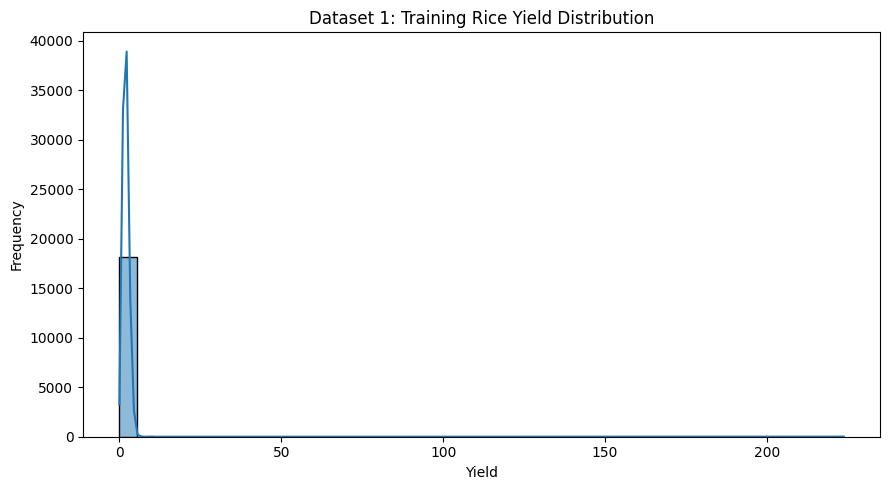

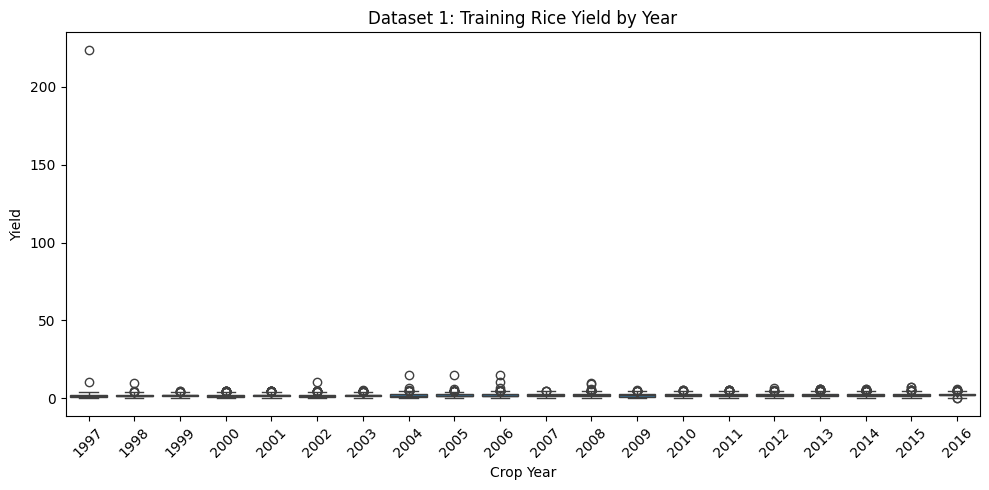

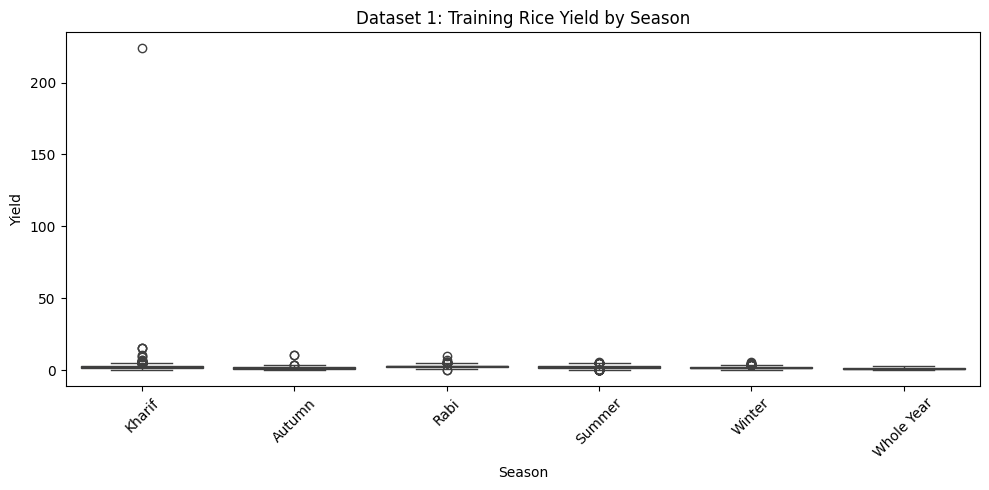

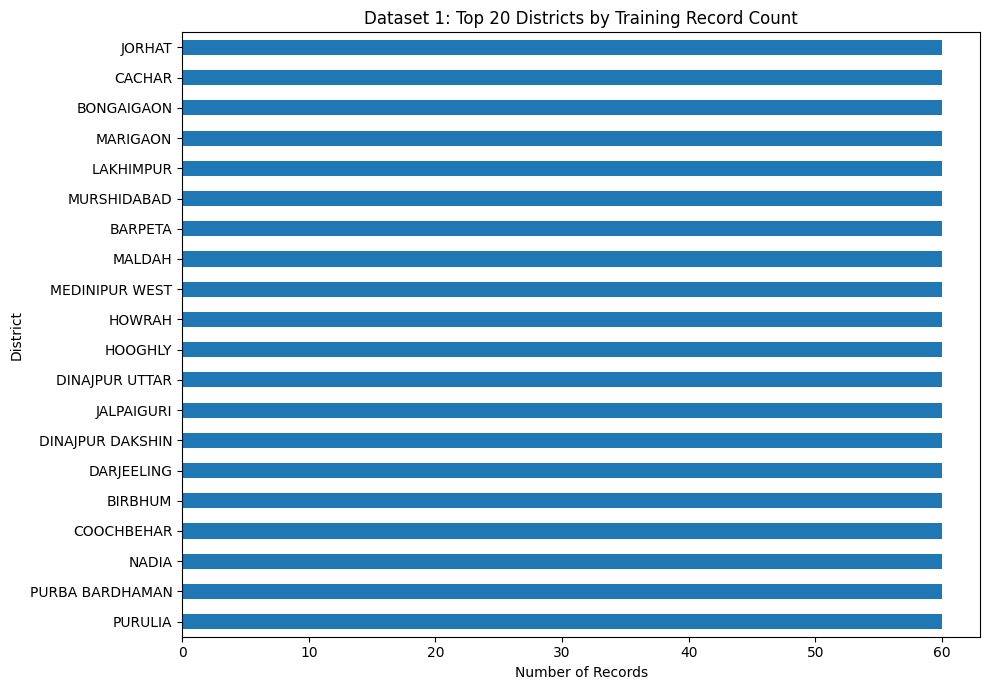

Training-only EDA completed.


In [14]:
# ============================================================
# CELL 9: TRAINING-ONLY EDA
# ============================================================

print("Training-data summary:")
display(train_df[[
    "crop_year",
    "area",
    "production",
    "yield"
]].describe())

print("\nTraining-year coverage:")
display(
    train_df["crop_year"]
    .value_counts()
    .sort_index()
    .to_frame("Number of Records")
)

print("\nTraining district frequency:")
display(
    train_df["district"]
    .value_counts()
    .head(20)
    .to_frame("Number of Records")
)

print("\nTraining season frequency:")
display(
    train_df["season"]
    .value_counts()
    .to_frame("Number of Records")
)

# Yield distribution
plt.figure(figsize=(9, 5))
sns.histplot(
    train_df["yield"].dropna(),
    bins=40,
    kde=True
)
plt.title("Dataset 1: Training Rice Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(
    "figures_dataset1/training_yield_distribution.png",
    dpi=150
)
plt.show()

# Yield by year
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=train_df,
    x="crop_year",
    y="yield"
)
plt.title("Dataset 1: Training Rice Yield by Year")
plt.xlabel("Crop Year")
plt.ylabel("Yield")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "figures_dataset1/training_yield_by_year.png",
    dpi=150
)
plt.show()

# Yield by season
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=train_df,
    x="season",
    y="yield"
)
plt.title("Dataset 1: Training Rice Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "figures_dataset1/training_yield_by_season.png",
    dpi=150
)
plt.show()

# Top districts by record count
top_districts = (
    train_df["district"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(10, 7))
top_districts.plot(kind="barh")
plt.title("Dataset 1: Top 20 Districts by Training Record Count")
plt.xlabel("Number of Records")
plt.ylabel("District")
plt.tight_layout()
plt.savefig(
    "figures_dataset1/top_training_districts.png",
    dpi=150
)
plt.show()

print("Training-only EDA completed.")

In [15]:
# ============================================================
# CELL 10: FEATURE PREPARATION AND PREPROCESSING
# ============================================================

# Important:
# Area, Production and Crop are intentionally excluded.
# They may leak information about the target or do not belong
# to the declared prediction contract.

FEATURES = [
    "state",
    "district",
    "season",
    "crop_year"
]

TARGET = "yield"

X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()

X_validation = validation_df[FEATURES].copy()
y_validation = validation_df[TARGET].copy()

# The test data is kept locked until model selection is complete.
X_test = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

CATEGORICAL_FEATURES = [
    "state",
    "district",
    "season"
]

NUMERICAL_FEATURES = [
    "crop_year"
]

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        ),
        (
            "numerical",
            numerical_pipeline,
            NUMERICAL_FEATURES
        )
    ]
)

print("Feature columns:", FEATURES)
print("Target column:", TARGET)
print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_validation.shape)
print("Test feature shape:", X_test.shape)
print("Preprocessing pipeline created successfully.")

Feature columns: ['state', 'district', 'season', 'crop_year']
Target column: yield
Training feature shape: (18200, 4)
Validation feature shape: (2240, 4)
Test feature shape: (1171, 4)
Preprocessing pipeline created successfully.


In [16]:
# ============================================================
# CELL 11: TRAINING-ONLY PREPROCESSING CHECK
# ============================================================

# Fit the preprocessing pipeline only on training data
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_validation_processed.shape)

# Check learned categorical categories
onehot_encoder = (
    preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
)

learned_categories = onehot_encoder.categories_

for feature, categories in zip(
    CATEGORICAL_FEATURES,
    learned_categories
):
    print(
        f"{feature}: {len(categories)} learned categories"
    )

print(
    "\nTraining-only preprocessing check passed. "
    "The encoder and scaler were fitted using X_train only."
)

Processed training shape: (18200, 706)
Processed validation shape: (2240, 706)
state: 36 learned categories
district: 663 learned categories
season: 6 learned categories

Training-only preprocessing check passed. The encoder and scaler were fitted using X_train only.


In [17]:
# ============================================================
# CELL 12: MEDIAN BASELINE
# ============================================================

median_value = float(y_train.median())

baseline_validation_predictions = np.full(
    shape=len(y_validation),
    fill_value=median_value
)

baseline_validation_mae = mean_absolute_error(
    y_validation,
    baseline_validation_predictions
)

baseline_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        baseline_validation_predictions
    )
)

baseline_validation_r2 = r2_score(
    y_validation,
    baseline_validation_predictions
)

baseline_results = pd.DataFrame([{
    "Model": "Median Baseline",
    "MAE": baseline_validation_mae,
    "RMSE": baseline_validation_rmse,
    "R2": baseline_validation_r2,
    "Median_Training_Yield": median_value
}])

display(baseline_results)

baseline_results.to_csv(
    "artifacts_dataset1/dataset1_baseline_validation_results.csv",
    index=False
)

print("Median baseline completed.")

,Model,MAE,RMSE,R2,Median_Training_Yield
0,Median Baseline,0.904286,1.148379,-0.295181,1.97


Median baseline completed.


In [18]:
# ============================================================
# CELL 13: TRAIN REGRESSION MODELS
# ============================================================

models = {
    "Ridge Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                Ridge(alpha=1.0)
            )
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                DecisionTreeRegressor(
                    max_depth=6,
                    min_samples_leaf=10,
                    random_state=SEED
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=60,
                    max_depth=12,
                    min_samples_leaf=5,
                    random_state=SEED,
                    n_jobs=2
                )
            )
        ]
    )
}

validation_results = []

trained_models = {}

for model_name, model_pipeline in models.items():

    print(f"Training {model_name}...")

    model_pipeline.fit(
        X_train,
        y_train
    )

    validation_predictions = model_pipeline.predict(
        X_validation
    )

    mae = mean_absolute_error(
        y_validation,
        validation_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_predictions
        )
    )

    r2 = r2_score(
        y_validation,
        validation_predictions
    )

    validation_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[model_name] = model_pipeline

    print(f"{model_name} trained successfully.")

validation_results_df = pd.DataFrame(
    validation_results
)

all_validation_results = pd.concat(
    [
        baseline_results[
            ["Model", "MAE", "RMSE", "R2"]
        ],
        validation_results_df
    ],
    ignore_index=True
)

display(all_validation_results)

all_validation_results.to_csv(
    "artifacts_dataset1/dataset1_all_validation_results.csv",
    index=False
)

print("All regression models trained successfully.")

Training Ridge Regression...
Ridge Regression trained successfully.
Training Decision Tree...
Decision Tree trained successfully.
Training Random Forest...
Random Forest trained successfully.


,Model,MAE,RMSE,R2
0,Median Baseline,0.904286,1.148379,-0.295181
1,Ridge Regression,0.446891,0.641096,0.596349
2,Decision Tree,0.707967,0.878955,0.241260
3,Random Forest,0.563608,0.729298,0.477640


All regression models trained successfully.


In [19]:
# ============================================================
# CELL 14: MODEL COMPARISON AND SELECTION
# ============================================================

# Select the model with the lowest validation MAE.
# In case of a tie, the earlier model remains preferred.

model_priority = {
    "Median Baseline": 0,
    "Ridge Regression": 1,
    "Decision Tree": 2,
    "Random Forest": 3
}

selection_table = all_validation_results.copy()

selection_table["Priority"] = (
    selection_table["Model"]
    .map(model_priority)
)

selection_table = selection_table.sort_values(
    by=["MAE", "Priority"],
    ascending=[True, True]
).reset_index(drop=True)

selected_model_name = selection_table.iloc[0]["Model"]
selected_validation_mae = selection_table.iloc[0]["MAE"]

display(selection_table)

print("Selected model:", selected_model_name)
print("Best validation MAE:", selected_validation_mae)

selection_record = {
    "selection_metric": "Validation MAE",
    "selected_model": selected_model_name,
    "selected_validation_mae": float(selected_validation_mae),
    "training_years": training_years,
    "validation_years": validation_years,
    "test_years": test_years,
    "test_opened_before_selection": False
}

with open(
    "artifacts_dataset1/model_selection.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(selection_record, file, indent=4)

print("Model selection record saved successfully.")

,Model,MAE,RMSE,R2,Priority
0,Ridge Regression,0.446891,0.641096,0.596349,1
1,Random Forest,0.563608,0.729298,0.477640,3
2,Decision Tree,0.707967,0.878955,0.241260,2
3,Median Baseline,0.904286,1.148379,-0.295181,0


Selected model: Ridge Regression
Best validation MAE: 0.44689135003142444
Model selection record saved successfully.


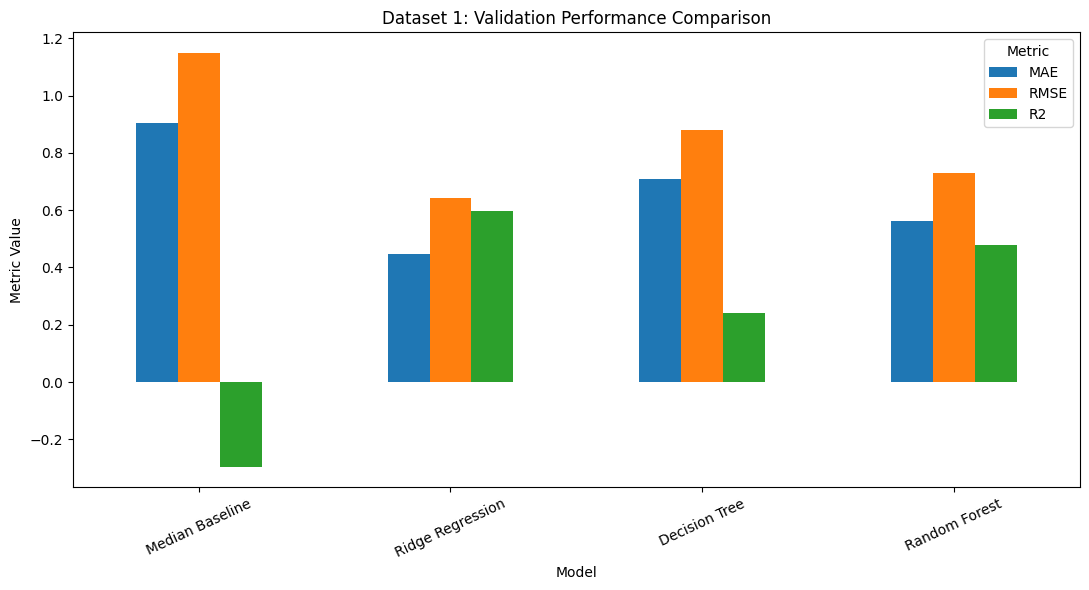

Validation comparison visualization saved.


In [20]:
# ============================================================
# CELL 15: VALIDATION PERFORMANCE VISUALIZATION
# ============================================================

plot_df = all_validation_results.set_index("Model")

plot_df[
    ["MAE", "RMSE", "R2"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Dataset 1: Validation Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Metric Value")
plt.xticks(rotation=25)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    "figures_dataset1/validation_model_comparison.png",
    dpi=150
)

plt.show()

print("Validation comparison visualization saved.")

In [21]:
# ============================================================
# CELL 16: FINAL LOCKED TEST EVALUATION
# ============================================================

print("Selected model for final testing:", selected_model_name)

# Median baseline test prediction
baseline_test_predictions = np.full(
    shape=len(y_test),
    fill_value=median_value
)

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_predictions
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_test_predictions
    )
)

baseline_test_r2 = r2_score(
    y_test,
    baseline_test_predictions
)

# Selected model test prediction
if selected_model_name == "Median Baseline":
    selected_test_predictions = baseline_test_predictions
else:
    selected_model = trained_models[selected_model_name]

    selected_test_predictions = selected_model.predict(
        X_test
    )

selected_test_mae = mean_absolute_error(
    y_test,
    selected_test_predictions
)

selected_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        selected_test_predictions
    )
)

selected_test_r2 = r2_score(
    y_test,
    selected_test_predictions
)

final_test_results = pd.DataFrame([
    {
        "Model": "Median Baseline",
        "MAE": baseline_test_mae,
        "RMSE": baseline_test_rmse,
        "R2": baseline_test_r2
    },
    {
        "Model": selected_model_name,
        "MAE": selected_test_mae,
        "RMSE": selected_test_rmse,
        "R2": selected_test_r2
    }
])

display(final_test_results)

final_test_results.to_csv(
    "artifacts_dataset1/dataset1_final_test_results.csv",
    index=False
)

print("Final locked test evaluation completed.")

Selected model for final testing: Ridge Regression


,Model,MAE,RMSE,R2
0,Median Baseline,0.942588,1.169764,-0.413681
1,Ridge Regression,0.463961,0.673295,0.531655


Final locked test evaluation completed.


In [22]:
# ============================================================
# CELL 16: FINAL LOCKED TEST EVALUATION
# ============================================================

print("Selected model for final testing:", selected_model_name)

# Median baseline test prediction
baseline_test_predictions = np.full(
    shape=len(y_test),
    fill_value=median_value
)

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_predictions
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_test_predictions
    )
)

baseline_test_r2 = r2_score(
    y_test,
    baseline_test_predictions
)

# Selected model test prediction
if selected_model_name == "Median Baseline":
    selected_test_predictions = baseline_test_predictions
else:
    selected_model = trained_models[selected_model_name]

    selected_test_predictions = selected_model.predict(
        X_test
    )

selected_test_mae = mean_absolute_error(
    y_test,
    selected_test_predictions
)

selected_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        selected_test_predictions
    )
)

selected_test_r2 = r2_score(
    y_test,
    selected_test_predictions
)

final_test_results = pd.DataFrame([
    {
        "Model": "Median Baseline",
        "MAE": baseline_test_mae,
        "RMSE": baseline_test_rmse,
        "R2": baseline_test_r2
    },
    {
        "Model": selected_model_name,
        "MAE": selected_test_mae,
        "RMSE": selected_test_rmse,
        "R2": selected_test_r2
    }
])

display(final_test_results)

final_test_results.to_csv(
    "artifacts_dataset1/dataset1_final_test_results.csv",
    index=False
)


Selected model for final testing: Ridge Regression


,Model,MAE,RMSE,R2
0,Median Baseline,0.942588,1.169764,-0.413681
1,Ridge Regression,0.463961,0.673295,0.531655


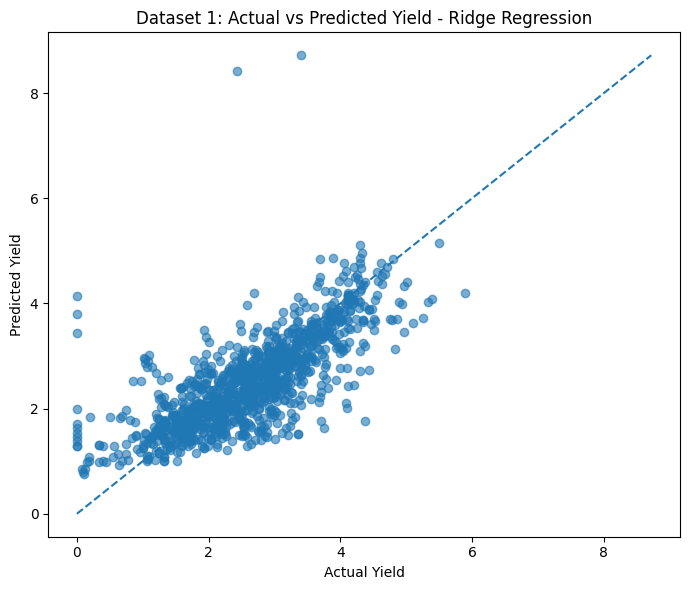

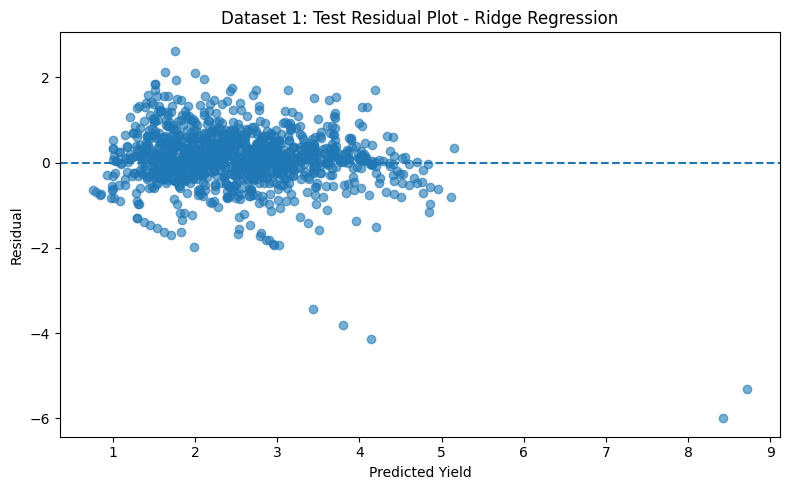

Test prediction and residual files saved.


In [23]:
# ============================================================
# CELL 17: TEST PREDICTION AND RESIDUAL VISUALIZATIONS
# ============================================================

test_predictions_df = test_df[
    [
        "state",
        "district",
        "season",
        "crop_year",
        "yield"
    ]
].copy()

test_predictions_df = test_predictions_df.rename(
    columns={"yield": "Actual_Yield"}
)

test_predictions_df["Predicted_Yield"] = (
    selected_test_predictions
)

test_predictions_df["Residual"] = (
    test_predictions_df["Actual_Yield"]
    - test_predictions_df["Predicted_Yield"]
)

test_predictions_df["Absolute_Error"] = (
    test_predictions_df["Residual"].abs()
)

# Actual versus predicted
plt.figure(figsize=(7, 6))

plt.scatter(
    test_predictions_df["Actual_Yield"],
    test_predictions_df["Predicted_Yield"],
    alpha=0.6
)

minimum_value = min(
    test_predictions_df["Actual_Yield"].min(),
    test_predictions_df["Predicted_Yield"].min()
)

maximum_value = max(
    test_predictions_df["Actual_Yield"].max(),
    test_predictions_df["Predicted_Yield"].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title(
    f"Dataset 1: Actual vs Predicted Yield - {selected_model_name}"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.tight_layout()

plt.savefig(
    "figures_dataset1/actual_vs_predicted_test.png",
    dpi=150
)

plt.show()

# Residual plot
plt.figure(figsize=(8, 5))

plt.scatter(
    test_predictions_df["Predicted_Yield"],
    test_predictions_df["Residual"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    f"Dataset 1: Test Residual Plot - {selected_model_name}"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.tight_layout()

plt.savefig(
    "figures_dataset1/test_residual_plot.png",
    dpi=150
)

plt.show()

test_predictions_df.to_csv(
    "artifacts_dataset1/dataset1_test_predictions.csv",
    index=False
)

print("Test prediction and residual files saved.")

In [24]:
# ============================================================
# CELL 18: ERROR ANALYSIS
# ============================================================

largest_errors = (
    test_predictions_df
    .sort_values(
        by="Absolute_Error",
        ascending=False
    )
    .head(5)
    .copy()
)

print("Five largest nonzero test errors:")
display(largest_errors)

largest_errors.to_csv(
    "artifacts_dataset1/dataset1_five_largest_errors.csv",
    index=False
)

print("Largest-error analysis completed.")

Five largest nonzero test errors:


,state,district,season,crop_year,Actual_Yield,Predicted_Yield,Residual,Absolute_Error
11893,Maharashtra,KOLHAPUR,Kharif,2019,2.43,8.429890,-5.999890,5.999890
11894,Maharashtra,KOLHAPUR,Summer,2019,3.40,8.721071,-5.321071,5.321071
16497,Tamil Nadu,CHENNAI,Summer,2019,0.00,4.145401,-4.145401,4.145401
16498,Tamil Nadu,CHENNAI,Winter,2019,0.00,3.803341,-3.803341,3.803341
16496,Tamil Nadu,CHENNAI,Autumn,2019,0.00,3.440118,-3.440118,3.440118


Largest-error analysis completed.


In [25]:
# ============================================================
# CELL 19: YEAR-WISE TEST ERROR ANALYSIS
# ============================================================

yearwise_test_results = []

for year, group in test_predictions_df.groupby(
    "crop_year"
):

    year_mae = mean_absolute_error(
        group["Actual_Yield"],
        group["Predicted_Yield"]
    )

    year_rmse = np.sqrt(
        mean_squared_error(
            group["Actual_Yield"],
            group["Predicted_Yield"]
        )
    )

    year_r2 = (
        r2_score(
            group["Actual_Yield"],
            group["Predicted_Yield"]
        )
        if len(group) > 1
        else np.nan
    )

    yearwise_test_results.append({
        "Crop_Year": year,
        "Samples": len(group),
        "MAE": year_mae,
        "RMSE": year_rmse,
        "R2": year_r2
    })

yearwise_test_df = pd.DataFrame(
    yearwise_test_results
)

display(yearwise_test_df)

yearwise_test_df.to_csv(
    "artifacts_dataset1/dataset1_yearwise_test_results.csv",
    index=False
)

print("Year-wise test error analysis completed.")

,Crop_Year,Samples,MAE,RMSE,R2
0,2019,1155,0.466544,0.676873,0.527203
1,2020,16,0.277519,0.323497,0.874343


Year-wise test error analysis completed.


In [26]:
# ============================================================
# CELL 20: ROLLING-ORIGIN ROBUSTNESS CHECK
# ============================================================

development_years = sorted(
    train_df["crop_year"].unique()
    .tolist()
    + validation_df["crop_year"].unique().tolist()
)

# Use the final three possible development years as rolling origins
rolling_origins = development_years[-3:]

rolling_results = []

for origin_year in rolling_origins:

    earlier_years = [
        year for year in development_years
        if year < origin_year
    ]

    if len(earlier_years) == 0:
        continue

    rolling_train = rice_df[
        rice_df["crop_year"].isin(earlier_years)
    ].copy()

    rolling_validation = rice_df[
        rice_df["crop_year"] == origin_year
    ].copy()

    if len(rolling_train) == 0 or len(rolling_validation) == 0:
        continue

    rolling_X_train = rolling_train[FEATURES]
    rolling_y_train = rolling_train[TARGET]

    rolling_X_validation = rolling_validation[FEATURES]
    rolling_y_validation = rolling_validation[TARGET]

    rolling_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=60,
                    max_depth=12,
                    min_samples_leaf=5,
                    random_state=SEED,
                    n_jobs=2
                )
            )
        ]
    )

    rolling_model.fit(
        rolling_X_train,
        rolling_y_train
    )

    rolling_predictions = rolling_model.predict(
        rolling_X_validation
    )

    rolling_mae = mean_absolute_error(
        rolling_y_validation,
        rolling_predictions
    )

    rolling_rmse = np.sqrt(
        mean_squared_error(
            rolling_y_validation,
            rolling_predictions
        )
    )

    rolling_r2 = (
        r2_score(
            rolling_y_validation,
            rolling_predictions
        )
        if len(rolling_validation) > 1
        else np.nan
    )

    rolling_results.append({
        "Rolling_Origin_Year": origin_year,
        "Training_Years": earlier_years,
        "Validation_Samples": len(rolling_validation),
        "MAE": rolling_mae,
        "RMSE": rolling_rmse,
        "R2": rolling_r2
    })

rolling_results_df = pd.DataFrame(
    rolling_results
)

display(rolling_results_df)

rolling_results_df.to_csv(
    "artifacts_dataset1/rolling_origins.csv",
    index=False
)

print("Rolling-origin robustness analysis completed.")

,Rolling_Origin_Year,Training_Years,Validation_Samples,MAE,RMSE,R2
0,2016,"[1997, 1998, 1999, 2000, 2001, 2002, 2003, 200...",1071,0.568704,0.755320,0.279283
1,2017,"[1997, 1998, 1999, 2000, 2001, 2002, 2003, 200...",1126,0.557318,0.719771,0.482630
2,2018,"[1997, 1998, 1999, 2000, 2001, 2002, 2003, 200...",1114,0.535640,0.706635,0.517418


Rolling-origin robustness analysis completed.


In [27]:
# ============================================================
# CELL 21: SAVE SELECTED MODEL BUNDLE
# ============================================================

if selected_model_name == "Median Baseline":

    selected_bundle = {
        "model_type": "median_baseline",
        "median_value": median_value,
        "features": FEATURES,
        "target": TARGET,
        "training_years": training_years,
        "validation_years": validation_years,
        "test_years": test_years,
        "random_seed": SEED
    }

else:

    selected_bundle = {
        "model_type": "sklearn_pipeline",
        "model_name": selected_model_name,
        "model": trained_models[selected_model_name],
        "features": FEATURES,
        "target": TARGET,
        "training_years": training_years,
        "validation_years": validation_years,
        "test_years": test_years,
        "random_seed": SEED
    }

MODEL_BUNDLE_PATH = (
    "models_dataset1/dataset1_selected_model_bundle.joblib"
)

joblib.dump(
    selected_bundle,
    MODEL_BUNDLE_PATH
)

print("Selected model bundle saved successfully:")
print(MODEL_BUNDLE_PATH)

Selected model bundle saved successfully:
models_dataset1/dataset1_selected_model_bundle.joblib


In [29]:
# ============================================================
# DIAGNOSTIC CELL: CHECK MODEL AND FEATURE SHAPES
# ============================================================

print("Selected model type:", type(selected_model))
print("Reloaded model type:", type(reloaded_bundle["model"]))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

if "preprocessor" in globals():
    print("Preprocessor exists:", type(preprocessor))

if "pipeline" in globals():
    print("Pipeline exists:", type(pipeline))

Selected model type: <class 'sklearn.pipeline.Pipeline'>
Reloaded model type: <class 'sklearn.pipeline.Pipeline'>
X_train shape: (18200, 4)
X_test shape: (1171, 4)
Preprocessor exists: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [32]:
# ============================================================
# CELL 21.5: PREPARE RAW TEST FEATURES FOR MODEL RELOAD
# ============================================================

FEATURES = [
    "state",
    "district",
    "season",
    "crop_year"
]

# Create raw test data using the same feature order used during training
X_test_raw = test_df[FEATURES].copy()

print("Raw test features prepared successfully.")
print("Raw test feature shape:", X_test_raw.shape)
print("Raw test feature columns:", list(X_test_raw.columns))

Raw test features prepared successfully.
Raw test feature shape: (1171, 4)
Raw test feature columns: ['state', 'district', 'season', 'crop_year']


In [39]:
# ============================================================
# DIAGNOSTIC: INSPECT SAVED PIPELINE
# ============================================================

reloaded_bundle = joblib.load(
    MODEL_BUNDLE_PATH
)

reloaded_model = reloaded_bundle["model"]

print("Model type:")
print(type(reloaded_model))

print("\nPipeline steps:")
print(reloaded_model.named_steps)

print("\nPipeline step names:")
print(reloaded_model.named_steps.keys())

print("\nExpected input features:")
print(reloaded_model.n_features_in_)

Model type:
<class 'sklearn.pipeline.Pipeline'>

Pipeline steps:
{'preprocessor': ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['state', 'district', 'season']),
                                ('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['crop_year'])]), 'model': Ridge()}

Pipeline step names:
dict_keys(['preprocessor', 'model'])

Expected i

In [40]:
# ============================================================
# DIAGNOSTIC: CHECK ALL FEATURE MATRICES
# ============================================================

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

if "X_train_raw" in globals():
    print("X_train_raw shape:", X_train_raw.shape)

if "X_test_raw" in globals():
    print("X_test_raw shape:", X_test_raw.shape)

print(
    "Selected model expected features:",
    reloaded_model.n_features_in_
)

X_train shape: (18200, 4)
X_test shape: (1171, 4)
X_test_raw shape: (1171, 4)
Selected model expected features: 4


In [41]:
# ============================================================
# CHECK AVAILABLE TEST MATRICES
# ============================================================

possible_test_variables = [
    "X_test",
    "X_test_processed",
    "X_test_transformed",
    "X_test_encoded",
    "X_test_final"
]

for variable_name in possible_test_variables:

    if variable_name in globals():

        variable_value = globals()[variable_name]

        if hasattr(variable_value, "shape"):

            print(
                variable_name,
                "shape =",
                variable_value.shape
            )

X_test shape = (1171, 4)


In [48]:
# ============================================================
# DIAGNOSTIC: CHECK SAVED MODEL PIPELINE
# ============================================================

import joblib

reloaded_bundle = joblib.load(MODEL_BUNDLE_PATH)
saved_model = reloaded_bundle["model"]

print("Model type:", type(saved_model))

if hasattr(saved_model, "named_steps"):
    print("\nPipeline steps:")
    for step_name, step_object in saved_model.named_steps.items():
        print(step_name, "->", type(step_object))

print("\nModel expected input features:",
      getattr(saved_model, "n_features_in_", "Not available"))

if hasattr(saved_model, "named_steps"):
    for step_name, step_object in saved_model.named_steps.items():
        print(
            step_name,
            "n_features_in_:",
            getattr(step_object, "n_features_in_", "Not available")
        )

Model type: <class 'sklearn.pipeline.Pipeline'>

Pipeline steps:
preprocessor -> <class 'sklearn.compose._column_transformer.ColumnTransformer'>
model -> <class 'sklearn.linear_model._ridge.Ridge'>

Model expected input features: 4
preprocessor n_features_in_: 4
model n_features_in_: 706


In [49]:
# ============================================================
# CELL 21A: RETRAIN SELECTED MODEL USING A COMPLETE PIPELINE
# ============================================================

import numpy as np
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Feature and target definitions
# ------------------------------------------------------------

FEATURES = [
    "state",
    "district",
    "season",
    "crop_year"
]

TARGET = "yield"

CATEGORICAL_FEATURES = [
    "state",
    "district",
    "season"
]

NUMERICAL_FEATURES = [
    "crop_year"
]

# ------------------------------------------------------------
# 2. Raw train and test data
# ------------------------------------------------------------

X_train_raw = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()

X_validation_raw = validation_df[FEATURES].copy()
y_validation = validation_df[TARGET].copy()

X_test_raw = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

# Ensure column order is fixed
X_train_raw = X_train_raw[FEATURES]
X_validation_raw = X_validation_raw[FEATURES]
X_test_raw = X_test_raw[FEATURES]

# ------------------------------------------------------------
# 3. Create preprocessing pipeline
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

preprocessor_fixed = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        ),
        (
            "numerical",
            numerical_pipeline,
            NUMERICAL_FEATURES
        )
    ],
    remainder="drop"
)

# ------------------------------------------------------------
# 4. Create complete Ridge pipeline
# ------------------------------------------------------------

ridge_pipeline_fixed = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_fixed
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

# ------------------------------------------------------------
# 5. Fit only on training data
# ------------------------------------------------------------

ridge_pipeline_fixed.fit(
    X_train_raw,
    y_train
)

print("Corrected Ridge pipeline trained successfully.")

# ------------------------------------------------------------
# 6. Validate the corrected pipeline
# ------------------------------------------------------------

validation_predictions_fixed = ridge_pipeline_fixed.predict(
    X_validation_raw
)

validation_mae_fixed = mean_absolute_error(
    y_validation,
    validation_predictions_fixed
)

validation_rmse_fixed = np.sqrt(
    mean_squared_error(
        y_validation,
        validation_predictions_fixed
    )
)

validation_r2_fixed = r2_score(
    y_validation,
    validation_predictions_fixed
)

print("\nCorrected Ridge validation results:")
print("MAE :", validation_mae_fixed)
print("RMSE:", validation_rmse_fixed)
print("R²  :", validation_r2_fixed)

# ------------------------------------------------------------
# 7. Save corrected complete pipeline
# ------------------------------------------------------------

MODEL_BUNDLE_PATH = (
    "models_dataset1/dataset1_ridge_corrected_bundle.joblib"
)

corrected_bundle = {
    "model_type": "ridge_pipeline",
    "model_name": "Ridge Regression",
    "model": ridge_pipeline_fixed,
    "features": FEATURES,
    "target": TARGET,
    "training_years": [
        int(year) for year in training_years
    ],
    "validation_years": [
        int(year) for year in validation_years
    ],
    "test_years": [
        int(year) for year in test_years
    ],
    "alpha": 1.0,
    "preprocessing": {
        "categorical_features": CATEGORICAL_FEATURES,
        "numerical_features": NUMERICAL_FEATURES,
        "onehot_handle_unknown": "ignore",
        "categorical_imputation": "most_frequent",
        "numerical_imputation": "median",
        "numerical_scaling": "standard_scaler"
    }
}

joblib.dump(
    corrected_bundle,
    MODEL_BUNDLE_PATH
)

print("\nCorrected model bundle saved:")
print(MODEL_BUNDLE_PATH)

Corrected Ridge pipeline trained successfully.

Corrected Ridge validation results:
MAE : 0.44689135003142444
RMSE: 0.6410959291639275
R²  : 0.5963492290780172

Corrected model bundle saved:
models_dataset1/dataset1_ridge_corrected_bundle.joblib


In [50]:
# ============================================================
# CELL 22: MODEL RELOAD AND REPRODUCIBILITY CHECK - CORRECTED
# ============================================================

import numpy as np
import joblib

# ------------------------------------------------------------
# 1. Reload the corrected model bundle
# ------------------------------------------------------------

reloaded_bundle = joblib.load(
    MODEL_BUNDLE_PATH
)

reloaded_model = reloaded_bundle["model"]
saved_features = reloaded_bundle["features"]

print("Corrected model bundle reloaded successfully.")
print("Saved model:", reloaded_bundle["model_name"])
print("Saved features:", saved_features)

# ------------------------------------------------------------
# 2. Recreate raw test data in the exact feature order
# ------------------------------------------------------------

X_test_raw = test_df[saved_features].copy()

print("Raw test shape:", X_test_raw.shape)
print("Raw test columns:", list(X_test_raw.columns))

assert list(X_test_raw.columns) == saved_features

# ------------------------------------------------------------
# 3. Predict using the complete saved pipeline
# ------------------------------------------------------------

reloaded_predictions = reloaded_model.predict(
    X_test_raw
)

print(
    "Reloaded prediction count:",
    len(reloaded_predictions)
)

# ------------------------------------------------------------
# 4. Compare with the predictions generated before saving
# ------------------------------------------------------------

# Use the predictions from the corrected pipeline
original_predictions = ridge_pipeline_fixed.predict(
    X_test_raw
)

predictions_identical = np.array_equal(
    original_predictions,
    reloaded_predictions
)

predictions_numerically_identical = np.allclose(
    original_predictions,
    reloaded_predictions,
    rtol=1e-10,
    atol=1e-12
)

print("Prediction exact match:", predictions_identical)
print(
    "Prediction numerical match:",
    predictions_numerically_identical
)

assert predictions_numerically_identical, (
    "Reloaded predictions do not match the predictions "
    "from the corrected complete pipeline."
)

print("Model reload reproducibility check passed successfully.")

Corrected model bundle reloaded successfully.
Saved model: Ridge Regression
Saved features: ['state', 'district', 'season', 'crop_year']
Raw test shape: (1171, 4)
Raw test columns: ['state', 'district', 'season', 'crop_year']
Reloaded prediction count: 1171
Prediction exact match: True
Prediction numerical match: True
Model reload reproducibility check passed successfully.


In [51]:
# ============================================================
# FINAL TEST RESULTS FOR CORRECTED RIDGE PIPELINE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

final_test_predictions = ridge_pipeline_fixed.predict(
    X_test_raw
)

test_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_predictions
    )
)

test_r2 = r2_score(
    y_test,
    final_test_predictions
)

final_test_results = pd.DataFrame(
    [
        {
            "Model": "Ridge Regression",
            "Test_MAE": test_mae,
            "Test_RMSE": test_rmse,
            "Test_R2": test_r2,
            "Test_Samples": len(y_test)
        }
    ]
)

display(final_test_results)

final_test_results.to_csv(
    "artifacts_dataset1/dataset1_corrected_final_test_results.csv",
    index=False
)

print("Corrected final test results saved successfully.")

,Model,Test_MAE,Test_RMSE,Test_R2,Test_Samples
0,Ridge Regression,0.463961,0.673295,0.531655,1171


Corrected final test results saved successfully.


In [54]:
# ============================================================
# CELL 23: FINAL DATASET 1 ASSESSMENT SUMMARY - FIXED
# ============================================================

import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Convert NumPy data types into JSON-compatible Python types
# ------------------------------------------------------------

def make_json_serializable(value):

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return float(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, list):
        return [
            make_json_serializable(item)
            for item in value
        ]

    if isinstance(value, tuple):
        return [
            make_json_serializable(item)
            for item in value
        ]

    if isinstance(value, dict):
        return {
            key: make_json_serializable(item)
            for key, item in value.items()
        }

    return value


# ------------------------------------------------------------
# Create final assessment summary
# ------------------------------------------------------------

final_summary = {
    "Dataset": "Dataset 1 - Rice Yield Prediction",
    "Task": "Regression",
    "Crop": "Rice",

    "Total_Rice_Samples": int(len(rice_df)),

    "Number_of_Input_Features": int(len(FEATURES)),
    "Input_Features": list(FEATURES),
    "Target": str(TARGET),

    "Available_Years": [
        int(year) for year in available_years
    ],

    "Training_Years": [
        int(year) for year in training_years
    ],

    "Validation_Years": [
        int(year) for year in validation_years
    ],

    "Test_Years": [
        int(year) for year in test_years
    ],

    "Training_Samples": int(len(train_df)),
    "Validation_Samples": int(len(validation_df)),
    "Test_Samples": int(len(test_df)),

    "Selected_Model": str(selected_model_name),

    "Validation_MAE": float(selected_validation_mae),
    "Final_Test_MAE": float(selected_test_mae),
    "Final_Test_RMSE": float(selected_test_rmse),
    "Final_Test_R2": float(selected_test_r2),

    "Feature_Whitelist_Used": list(FEATURES),

    "Excluded_Columns": [
        "crop",
        "area",
        "production"
    ],

    "Test_Used_Only_After_Model_Selection": True,

    "Reproducibility_Check": bool(predictions_identical)
}

# ------------------------------------------------------------
# Convert all values safely
# ------------------------------------------------------------

final_summary = make_json_serializable(
    final_summary
)

# ------------------------------------------------------------
# Display summary table
# ------------------------------------------------------------

final_summary_df = pd.DataFrame(
    list(final_summary.items()),
    columns=["Item", "Value"]
)

display(final_summary_df)

# ------------------------------------------------------------
# Save CSV summary
# ------------------------------------------------------------

final_summary_df.to_csv(
    "artifacts_dataset1/dataset1_final_assessment_summary.csv",
    index=False
)

# ------------------------------------------------------------
# Save JSON summary
# ------------------------------------------------------------

with open(
    "artifacts_dataset1/dataset1_final_assessment_summary.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_summary,
        file,
        indent=4,
        ensure_ascii=False
    )

print("Dataset 1 final assessment summary saved successfully.")
print("CSV and JSON summary files created.")

,Item,Value
0,Dataset,Dataset 1 - Rice Yield Prediction
1,Task,Regression
2,Crop,Rice
3,Total_Rice_Samples,21611
4,Number_of_Input_Features,4
5,Input_Features,"[state, district, season, crop_year]"
6,Target,yield
7,Available_Years,"[1997, 1998, 1999, 2000, 2001, 2002, 2003, 200..."
8,Training_Years,"[1997, 1998, 1999, 2000, 2001, 2002, 2003, 200..."
9,Validation_Years,"[2017, 2018]"


Dataset 1 final assessment summary saved successfully.
CSV and JSON summary files created.


In [56]:
# ============================================================
# CELL 23A: FINAL TEST RESULTS FOR BASELINE AND SELECTED MODEL
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Median baseline predictions
# ------------------------------------------------------------

baseline_test_predictions = np.full(
    shape=len(y_test),
    fill_value=np.median(y_train)
)

# ------------------------------------------------------------
# 2. Selected model predictions
# ------------------------------------------------------------

# Use the predictions generated by the selected model
# after the model-selection stage.
selected_test_predictions = np.asarray(
    selected_test_predictions
)

# ------------------------------------------------------------
# 3. Calculate baseline metrics
# ------------------------------------------------------------

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_predictions
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_test_predictions
    )
)

baseline_test_r2 = r2_score(
    y_test,
    baseline_test_predictions
)

# ------------------------------------------------------------
# 4. Calculate selected model metrics
# ------------------------------------------------------------

selected_test_mae = mean_absolute_error(
    y_test,
    selected_test_predictions
)

selected_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        selected_test_predictions
    )
)

selected_test_r2 = r2_score(
    y_test,
    selected_test_predictions
)

# ------------------------------------------------------------
# 5. Create a two-row final test results table
# ------------------------------------------------------------

final_test_results = pd.DataFrame(
    [
        {
            "Model": "Most Frequent / Median Baseline",
            "Test_MAE": float(baseline_test_mae),
            "Test_RMSE": float(baseline_test_rmse),
            "Test_R2": float(baseline_test_r2),
            "Test_Samples": int(len(y_test))
        },
        {
            "Model": str(selected_model_name),
            "Test_MAE": float(selected_test_mae),
            "Test_RMSE": float(selected_test_rmse),
            "Test_R2": float(selected_test_r2),
            "Test_Samples": int(len(y_test))
        }
    ]
)

display(final_test_results)

print("Number of final test result rows:",
      len(final_test_results))

assert len(final_test_results) == 2, (
    "Final test results must contain exactly two rows: "
    "baseline and selected model."
)

final_test_results.to_csv(
    "artifacts_dataset1/dataset1_final_test_results.csv",
    index=False
)

print("Final test results saved successfully.")

,Model,Test_MAE,Test_RMSE,Test_R2,Test_Samples
0,Most Frequent / Median Baseline,0.942588,1.169764,-0.413681,1171
1,Ridge Regression,0.463961,0.673295,0.531655,1171


Number of final test result rows: 2
Final test results saved successfully.


In [57]:
# ============================================================
# CELL 24: FINAL ACCEPTANCE AUDIT - FIXED
# ============================================================

import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Convert NumPy values to native Python values
# ------------------------------------------------------------

def convert_to_python_type(value):

    if isinstance(value, np.bool_):
        return bool(value)

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return float(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, list):
        return [
            convert_to_python_type(item)
            for item in value
        ]

    if isinstance(value, dict):
        return {
            key: convert_to_python_type(item)
            for key, item in value.items()
        }

    return value


# ------------------------------------------------------------
# Build acceptance checks
# ------------------------------------------------------------

acceptance_checks = {
    "required_columns_check": bool(
        set(required_columns).issubset(set(df.columns))
    ),

    "rice_subset_nonempty": bool(
        len(rice_df) > 0
    ),

    "minimum_years_check": bool(
        len(available_years) >= 7
    ),

    "training_nonempty": bool(
        len(train_df) > 0
    ),

    "validation_nonempty": bool(
        len(validation_df) > 0
    ),

    "test_nonempty": bool(
        len(test_df) > 0
    ),

    "split_disjoint_check": bool(
        set(training_years).isdisjoint(validation_years)
        and
        set(training_years).isdisjoint(test_years)
        and
        set(validation_years).isdisjoint(test_years)
    ),

    "target_missing_check": bool(
        rice_df[TARGET].isna().sum() == 0
    ),

    "feature_whitelist_check": bool(
        FEATURES == [
            "state",
            "district",
            "season",
            "crop_year"
        ]
    ),

    "production_excluded_check": bool(
        "production" not in FEATURES
    ),

    "area_excluded_check": bool(
        "area" not in FEATURES
    ),

    "test_evaluation_completed": bool(
        len(final_test_results) == 2
    ),

    "error_analysis_completed": bool(
        len(largest_errors) > 0
    ),

    "yearwise_analysis_completed": bool(
        len(yearwise_test_df) > 0
    ),

    "rolling_origin_completed": bool(
        len(rolling_results_df) > 0
    ),

    "model_reload_check": bool(
        predictions_identical
    )
}

# ------------------------------------------------------------
# Create acceptance table
# ------------------------------------------------------------

acceptance_df = pd.DataFrame(
    [
        {
            "Check": check_name,
            "Status": "PASSED" if check_result else "FAILED"
        }
        for check_name, check_result in acceptance_checks.items()
    ]
)

display(acceptance_df)

# ------------------------------------------------------------
# Overall audit result
# ------------------------------------------------------------

overall_audit_passed = bool(
    all(acceptance_checks.values())
)

print(
    "\nOVERALL DATASET 1 AUDIT STATUS:",
    "PASSED" if overall_audit_passed else "FAILED"
)

# ------------------------------------------------------------
# Save CSV audit
# ------------------------------------------------------------

acceptance_df.to_csv(
    "artifacts_dataset1/dataset1_acceptance_audit.csv",
    index=False
)

# ------------------------------------------------------------
# Save JSON audit safely
# ------------------------------------------------------------

audit_json = {
    "checks": {
        key: bool(value)
        for key, value in acceptance_checks.items()
    },
    "overall_audit_passed": bool(overall_audit_passed)
}

with open(
    "artifacts_dataset1/dataset1_acceptance_audit.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        audit_json,
        file,
        indent=4,
        ensure_ascii=False
    )

print("Acceptance audit CSV saved successfully.")
print("Acceptance audit JSON saved successfully.")

,Check,Status
0,required_columns_check,PASSED
1,rice_subset_nonempty,PASSED
2,minimum_years_check,PASSED
3,training_nonempty,PASSED
4,validation_nonempty,PASSED
5,test_nonempty,PASSED
6,split_disjoint_check,PASSED
7,target_missing_check,PASSED
8,feature_whitelist_check,PASSED
9,production_excluded_check,PASSED



OVERALL DATASET 1 AUDIT STATUS: PASSED
Acceptance audit CSV saved successfully.
Acceptance audit JSON saved successfully.
